In [1]:
import pandas as pd
import matplotlib.pyplot as plt

campaign = pd.read_csv(
    "../data/processed/campaign_performance.csv"
)

channel = pd.read_csv(
    "../data/processed/channel_performance.csv"
)

monthly = pd.read_csv(
    "../data/processed/monthly_performance.csv"
)

lead_quality = pd.read_csv(
    "../data/processed/lead_quality.csv"
)

In [2]:
campaign.info()
campaign.describe()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   campaign_id         120 non-null    str    
 1   campaign_name       120 non-null    str    
 2   channel             120 non-null    str    
 3   objective           120 non-null    str    
 4   start_date          120 non-null    str    
 5   end_date            120 non-null    str    
 6   budget              120 non-null    float64
 7   total_spend         120 non-null    float64
 8   impressions         120 non-null    int64  
 9   clicks              120 non-null    int64  
 10  total_leads         120 non-null    int64  
 11  avg_lead_score      120 non-null    float64
 12  total_conversions   120 non-null    int64  
 13  purchases           120 non-null    int64  
 14  trials              120 non-null    int64  
 15  total_revenue       120 non-null    float64
 16  budget_utilization 

,budget,total_spend,impressions,clicks,total_leads,avg_lead_score,total_conversions,purchases,trials,total_revenue,budget_utilization,ctr,purchase_rate,roas,cost_per_purchase,revenue_per_lead
count,120.000000,120.000000,1.200000e+02,120.000000,120.000000,120.000000,120.00000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,45155.351333,37692.083500,3.640373e+06,59185.991667,2180.700000,50.568583,330.80000,139.091667,191.708333,179681.991750,83.749083,1.854500,6.387667,5.220583,314.363917,82.775833
std,20913.614575,17452.690795,2.306184e+06,41308.574489,1098.132522,0.860194,166.05105,70.026405,96.926932,90749.190614,7.239993,1.064354,0.654746,2.703270,150.418847,9.271571
min,8102.320000,6105.330000,4.069900e+05,3640.000000,145.000000,46.980000,14.00000,7.000000,7.000000,11132.240000,69.880000,0.580000,3.290000,1.820000,102.200000,48.210000
25%,27094.592500,22101.795000,1.893437e+06,27920.000000,1409.250000,50.037500,220.75000,91.750000,130.000000,120515.167500,77.695000,0.890000,6.040000,3.252500,190.340000,76.800000
50%,48059.120000,38814.665000,3.241162e+06,49272.000000,1947.500000,50.605000,305.00000,128.500000,174.500000,167908.085000,84.345000,1.800000,6.320000,4.385000,298.970000,82.035000
75%,61425.745000,51863.862500,4.759480e+06,80969.250000,2951.750000,50.997500,441.75000,185.250000,255.250000,233169.710000,89.372500,2.522500,6.725000,6.720000,396.460000,87.710000
max,79884.920000,72153.850000,1.110054e+07,174518.000000,5104.000000,53.860000,768.00000,326.000000,442.000000,417738.920000,98.680000,3.570000,8.090000,13.010000,872.190000,119.760000


In [3]:
campaign[
    [
        "total_spend",
        "total_revenue",
        "purchases",
        "total_leads",
        "avg_lead_score",
        "roas"
    ]
].corr()

,total_spend,total_revenue,purchases,total_leads,avg_lead_score,roas
total_spend,1.000000,0.598586,0.607903,0.623922,-0.036023,-0.365071
total_revenue,0.598586,1.000000,0.996109,0.984773,0.025042,0.426061
purchases,0.607903,0.996109,1.000000,0.988824,0.021489,0.414420
total_leads,0.623922,0.984773,0.988824,1.000000,0.005272,0.384346
avg_lead_score,-0.036023,0.025042,0.021489,0.005272,1.000000,0.106531
roas,-0.365071,0.426061,0.414420,0.384346,0.106531,1.000000


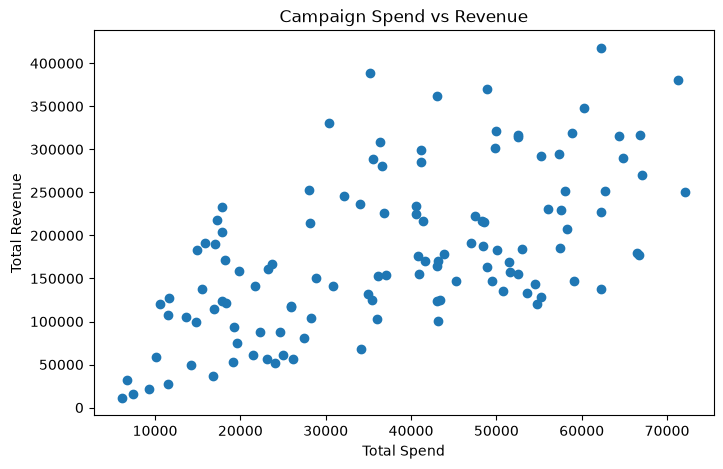

In [4]:
plt.figure(figsize=(8, 5))

plt.scatter(
    campaign["total_spend"],
    campaign["total_revenue"]
)

plt.xlabel("Total Spend")
plt.ylabel("Total Revenue")
plt.title("Campaign Spend vs Revenue")

plt.show()

In [5]:
campaign["purchase_rate"] = (
    100 * campaign["purchases"]
    / campaign["total_leads"]
)

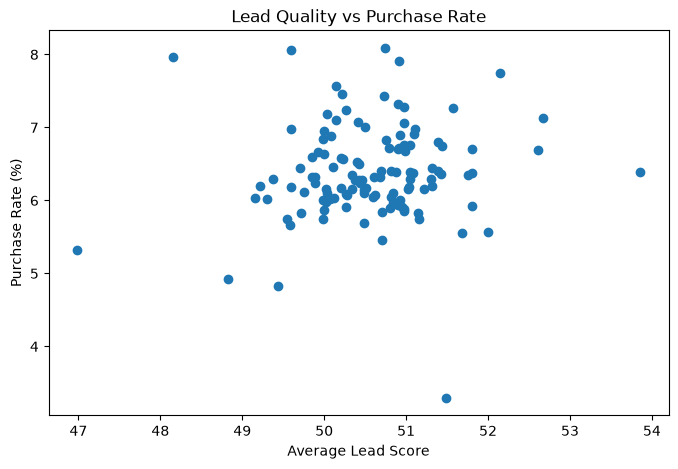

In [6]:
plt.figure(figsize=(8, 5))

plt.scatter(
    campaign["avg_lead_score"],
    campaign["purchase_rate"]
)

plt.xlabel("Average Lead Score")
plt.ylabel("Purchase Rate (%)")
plt.title("Lead Quality vs Purchase Rate")

plt.show()

In [7]:
top_campaigns = campaign.sort_values(
    "roas",
    ascending=False
).head(10)

top_campaigns[
    [
        "campaign_name",
        "channel",
        "objective",
        "total_spend",
        "total_revenue",
        "purchases",
        "roas"
    ]
]

,campaign_name,channel,objective,total_spend,total_revenue,purchases,roas
30,Affiliate 2024 080,affiliate,awareness,17904.18,232990.96,172,13.01
37,Affiliate 2024 070,affiliate,awareness,17318.50,218374.17,167,12.61
51,Affiliate 2023 040,affiliate,awareness,14920.90,183150.82,146,12.27
45,Affiliate 2025 035,affiliate,awareness,15913.35,191083.78,142,12.01
90,Affiliate 2024 045,affiliate,awareness,10543.72,120094.29,88,11.39
43,Affiliate 2025 095,affiliate,acquisition,17881.69,203419.10,166,11.38
46,Affiliate 2024 005,affiliate,acquisition,17057.46,189914.53,143,11.13
1,Affiliate 2023 050,affiliate,awareness,35219.40,388919.88,299,11.04
6,Affiliate 2025 110,affiliate,acquisition,30384.26,330555.85,257,10.88
83,Paid Search 2023 086,paid_search,awareness,11691.91,126855.40,101,10.85
